## 0. Installation Check (Run First)

In [95]:
# Check and install TensorFlow if needed
import subprocess
import sys

def check_install_tensorflow():
    try:
        import tensorflow as tf
        print(f"✅ TensorFlow {tf.__version__} already installed")
        return True
    except ImportError:
        print("⚠️  TensorFlow not found. Installing...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow", "-q"])
            print("✅ TensorFlow installed successfully!")
            return True
        except Exception as e:
            print(f"❌ Failed to install TensorFlow: {e}")
            print("\nManual installation: pip install tensorflow")
            return False

check_install_tensorflow()

# Check other dependencies
try:
    import openpyxl
    print("✅ openpyxl available")
except ImportError:
    print("⚠️  Installing openpyxl for Excel support...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl", "-q"])
    print("✅ openpyxl installed")

✅ TensorFlow 2.20.0 already installed
✅ openpyxl available


# Deep Neural Network Analysis: Water Dataset
## Comprehensive DNN Modeling with MLP, CNN, and LSTM

**Dataset:** water_dataset_with_rates_11-04-2025.xlsx

**Objectives:**
1. Apply 3 Deep Neural Network architectures
2. Compare model performance
3. Generate comprehensive results for technical paper

**Models:**
- **MLP (Multi-Layer Perceptron)** - Fully connected feedforward network
- **CNN (Convolutional Neural Network)** - 1D convolutions for feature extraction
- **LSTM (Long Short-Term Memory)** - Recurrent network for temporal patterns

**Author:** [Your Name]  
**Date:** November 2025

## 1. Environment Setup

In [96]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf  # type: ignore
from tensorflow import keras  # type: ignore
from tensorflow.keras.models import Sequential  # type: ignore
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LSTM, Conv1D, MaxPooling1D, Flatten, Input, Bidirectional  # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint  # type: ignore
from tensorflow.keras.optimizers import Adam  # type: ignore
from tensorflow.keras import regularizers  # type: ignore

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Set random seeds
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("="*80)
print("DEEP NEURAL NETWORK - WATER DATASET ANALYSIS")
print("="*80)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Random seed: {RANDOM_SEED}")
print("="*80)

DEEP NEURAL NETWORK - WATER DATASET ANALYSIS
TensorFlow version: 2.20.0
GPU available: False
Random seed: 42


## 2. Data Loading and Exploration

In [97]:
# Load dataset
df = pd.read_excel('water_dataset_with_rates_11-04-2025.xlsx')

print("Dataset Information:")
print("="*80)
print(f"Shape: {df.shape}")
print(f"Samples: {df.shape[0]}")
print(f"Features: {df.shape[1]}")
print(f"\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col} ({df[col].dtype})")

print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nStatistics:")
print(df.describe())

print(f"\nMissing values:")
print(df.isnull().sum().sum(), "total missing values")
print("="*80)

Dataset Information:
Shape: (5424, 24)
Samples: 5424
Features: 24

Columns:
  1. YEAR (int64)
  2. HOUSING_FINAL_COUNT (int64)
  3. NO_OF_CUSTOMERS (int64)
  4. BILLED_VOLUME_M3 (int64)
  5. PRICE_PER_M3 (float64)
  6. CMD (float64)
  7. NEW_LOC_CODE (object)
  8. HOUSING_TYPE (object)
  9. LOCATION (object)
  10. MONTH_NUM (int64)
  11. MONTH_YEAR (datetime64[ns])
  12. M3_PER_CUSTOMER (float64)
  13. REGION (object)
  14. POP_GR_SCENARIO_1 (float64)
  15. POP_GR_SCENARIO_2 (float64)
  16. POP_GR_SCENARIO_3 (float64)
  17. INFLATION_RATE (float64)
  18. HOUSING_PRINDEX_ALLTYPE (float64)
  19. HOUSING_PRINDEX_CONDO (float64)
  20. HOUSING_PRINDEX_HOUSE (float64)
  21. PSA HOUSETYPE (object)
  22. AVG_HOUSEHOLD_SIZE (float64)
  23. HH_POP_CALC (float64)
  24. HH_POP_PSA (float64)

First 5 rows:
   YEAR  HOUSING_FINAL_COUNT  NO_OF_CUSTOMERS  BILLED_VOLUME_M3  PRICE_PER_M3  \
0  2023                  347              333              8746         40.63   
1  2023                  208     

## 3. Data Preprocessing

In [98]:
# Handle missing values
df_clean = df.dropna()
print(f"Removed {len(df) - len(df_clean)} rows with missing values")

# Identify numeric and non-numeric columns
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_columns = df_clean.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nColumn Analysis:")
print(f"  Numeric columns ({len(numeric_columns)}): {numeric_columns}")
print(f"  Non-numeric columns ({len(non_numeric_columns)}): {non_numeric_columns}")

# Define features and target using ONLY numeric columns
target_column = numeric_columns[-1]
feature_columns = [col for col in numeric_columns if col != target_column]

print(f"\nTarget variable: '{target_column}'")
print(f"Feature count: {len(feature_columns)}")

# Extract numeric data and convert to float explicitly
X = df_clean[feature_columns].values.astype(np.float64)
y = df_clean[target_column].values.astype(np.float64)

# Remove outliers using IQR method
from scipy import stats
z_scores = np.abs(stats.zscore(y))
mask = z_scores < 3  # Keep samples within 3 standard deviations
X = X[mask]
y = y[mask]

print(f"\nAfter outlier removal:")
print(f"  Samples: {len(X)}")
print(f"  Target mean: {y.mean():.2f}")
print(f"  Target std: {y.std():.2f}")
print(f"  Target range: [{y.min():.2f}, {y.max():.2f}]")

Removed 195 rows with missing values

Column Analysis:
  Numeric columns (18): ['YEAR', 'HOUSING_FINAL_COUNT', 'NO_OF_CUSTOMERS', 'BILLED_VOLUME_M3', 'PRICE_PER_M3', 'CMD', 'MONTH_NUM', 'M3_PER_CUSTOMER', 'POP_GR_SCENARIO_1', 'POP_GR_SCENARIO_2', 'POP_GR_SCENARIO_3', 'INFLATION_RATE', 'HOUSING_PRINDEX_ALLTYPE', 'HOUSING_PRINDEX_CONDO', 'HOUSING_PRINDEX_HOUSE', 'AVG_HOUSEHOLD_SIZE', 'HH_POP_CALC', 'HH_POP_PSA']
  Non-numeric columns (6): ['NEW_LOC_CODE', 'HOUSING_TYPE', 'LOCATION', 'MONTH_YEAR', 'REGION', 'PSA HOUSETYPE']

Target variable: 'HH_POP_PSA'
Feature count: 17

After outlier removal:
  Samples: 5229
  Target mean: 2259154.13
  Target std: 4449991.45
  Target range: [36.00, 12254076.00]


In [99]:
# Split data: 60% train, 20% validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_SEED)  # 0.25 * 0.80 = 0.20

print("Data Split:")
print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val:   {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nExpected split: 60% train, 20% validation, 20% test")

Data Split:
Train: 3137 (60.0%)
Val:   1046 (20.0%)
Test:  1046 (20.0%)

Expected split: 60% train, 20% validation, 20% test


In [100]:
# Feature scaling with robust scaling
from sklearn.preprocessing import RobustScaler

# Use RobustScaler (better for outliers)
scaler_robust = RobustScaler()
X_train_scaled = scaler_robust.fit_transform(X_train)
X_val_scaled = scaler_robust.transform(X_val)
X_test_scaled = scaler_robust.transform(X_test)

# For LSTM (MinMaxScaler)
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_val_minmax = scaler_minmax.transform(X_val)
X_test_minmax = scaler_minmax.transform(X_test)

X_train_lstm = X_train_minmax.reshape((X_train_minmax.shape[0], 1, X_train_minmax.shape[1]))
X_val_lstm = X_val_minmax.reshape((X_val_minmax.shape[0], 1, X_val_minmax.shape[1]))
X_test_lstm = X_test_minmax.reshape((X_test_minmax.shape[0], 1, X_test_minmax.shape[1]))

# For CNN
X_train_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_val_cnn = X_val_scaled.reshape((X_val_scaled.shape[0], X_val_scaled.shape[1], 1))
X_test_cnn = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

print("Scaled data ready (RobustScaler used):")
print(f"MLP:  {X_train_scaled.shape}")
print(f"CNN:  {X_train_cnn.shape}")
print(f"LSTM: {X_train_lstm.shape}")

Scaled data ready (RobustScaler used):
MLP:  (3137, 17)
CNN:  (3137, 17, 1)
LSTM: (3137, 1, 17)


## 4. Model 1: Multi-Layer Perceptron (MLP)

In [101]:
# Build IMPROVED MLP with deeper architecture
def build_mlp(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        
        # Deeper network with more capacity
        Dense(256, kernel_regularizer=regularizers.l2(0.0001)),
        BatchNormalization(),
        keras.layers.Activation('relu'),
        Dropout(0.4),
        
        Dense(128, kernel_regularizer=regularizers.l2(0.0001)),
        BatchNormalization(),
        keras.layers.Activation('relu'),
        Dropout(0.3),
        
        Dense(64, kernel_regularizer=regularizers.l2(0.0001)),
        BatchNormalization(),
        keras.layers.Activation('relu'),
        Dropout(0.2),
        
        Dense(32, kernel_regularizer=regularizers.l2(0.0001)),
        BatchNormalization(),
        keras.layers.Activation('relu'),
        Dropout(0.1),
        
        Dense(1, activation='linear')
    ], name='MLP')
    return model

mlp_model = build_mlp(X_train_scaled.shape[1])
mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='huber',  # More robust to outliers than MSE
    metrics=['mae', 'mse']
)

print("IMPROVED MLP Architecture:")
mlp_model.summary()
print(f"\nTotal parameters: {mlp_model.count_params():,}")

IMPROVED MLP Architecture:


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_49 (Dense)                │ (None, 256)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_41 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_42 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,793 (194.50 KB)

 Trainable params: 48,833 (190.75 KB)

 Non-trainable params: 960 (3.75 KB)


Total parameters: 49,793


In [102]:
# Train MLP with improved callbacks
mlp_callbacks = [
    EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_mlp_model.h5', monitor='val_loss', save_best_only=True, verbose=0)
]

print("Training MLP (this may take a few minutes)...")
mlp_history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    batch_size=16,  # Smaller batch for better generalization
    epochs=300,  # More epochs with early stopping
    callbacks=mlp_callbacks,
    verbose=1
)

print(f"\n✅ MLP training complete! Stopped at epoch {len(mlp_history.history['loss'])}")

Training MLP (this may take a few minutes)...
Epoch 1/300
146/197 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step - loss: 2227837.2500 - mae: 2227837.7500 - mse: 24305863753728.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2329057.2500 - mae: 2329057.7500 - mse: 25739623661568.0000 - val_loss: 2127397.5000 - val_mae: 2127398.0000 - val_mse: 23101872013312.0000 - learning_rate: 0.0010
Epoch 2/300
  1/197 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 995856.8750 - mae: 995857.4375 - mse: 9834894196736.0000Epoch 2/300
153/197 ━━━━━━━━━━━━━━━━━━━━ 0s 664us/step - loss: 2230693.7500 - mae: 2230694.2500 - mse: 24348840689664.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - loss: 2329049.7500 - mae: 2329050.2500 - mse: 25739592204288.0000 - val_loss: 2127385.2500 - val_mae: 2127385.5000 - val_mse: 23101813293056.0000 - learning_rate: 0.0010
Epoch 3/300
Epoch 3/300
147/197 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step - loss: 2228291.2500 - mae: 2228291.5000 - mse: 24312750800896.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step - loss: 2329037.2500 - mae: 2329037.5000 - mse: 25739527192576.0000 - val_loss: 2127368.2500 - val_mae: 2127368.7500 - val_mse: 23101750378496.0000 - learning_rate: 0.0010
Epoch 4/300
  1/197 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 995830.8125 - mae: 995831.3125 - mse: 9834858545152.0000Epoch 4/300
141/197 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - loss: 2225279.7500 - mae: 2225280.0000 - mse: 24268144377856.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2329016.2500 - mae: 2329016.7500 - mse: 25739460083712.0000 - val_loss: 2127340.5000 - val_mae: 2127341.0000 - val_mse: 23101676978176.0000 - learning_rate: 0.0010
Epoch 5/300
  1/197 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 995805.4375 - mae: 995805.9375 - mse: 9834837573632.0000Epoch 5/300
131/197 ━━━━━━━━━━━━━━━━━━━━ 0s 779us/step - loss: 2218028.0000 - mae: 2218028.5000 - mse: 24165214060544.0000

...

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step - loss: 2237471.0000 - mae: 2237471.0000 - mse: 24742033620992.0000 - val_loss: 2047607.1250 - val_mae: 2047607.2500 - val_mse: 22330979909632.0000 - learning_rate: 0.0010
Epoch 294/300
  1/197 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 917810.1875 - mae: 917810.1250 - mse: 9227505500160.0000Epoch 294/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2236514.0000 - mae: 2236514.0000 - mse: 24731174567936.0000 - val_loss: 2048521.5000 - val_mae: 2048521.5000 - val_mse: 22345697722368.0000 - learning_rate: 0.0010
Epoch 295/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2236514.0000 - mae: 2236514.0000 - mse: 24731174567936.0000 - val_loss: 2048521.5000 - val_mae: 2048521.5000 - val_mse: 22345697722368.0000 - learning_rate: 0.0010
Epoch 295/300
162/197 ━━━━━━━━━━━━━━━━━━━━ 0s 627us/step - loss: 2142802.0000 - mae: 2142802.0000 - mse: 23416910381056.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step - loss: 2236449.5000 - mae: 2236449.5000 - mse: 24718014939136.0000 - val_loss: 2045873.1250 - val_mae: 2045873.1250 - val_mse: 22318111784960.0000 - learning_rate: 0.0010
Epoch 296/300
Epoch 296/300
142/197 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - loss: 2134207.5000 - mae: 2134207.5000 - mse: 23297385299968.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 977us/step - loss: 2236586.5000 - mae: 2236586.5000 - mse: 24720829317120.0000 - val_loss: 2044476.0000 - val_mae: 2044476.0000 - val_mse: 22302225858560.0000 - learning_rate: 0.0010
Epoch 297/300
Epoch 297/300
141/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2132603.2500 - mae: 2132603.2500 - mse: 23260458647552.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2235219.7500 - mae: 2235219.7500 - mse: 24711985627136.0000 - val_loss: 2044412.3750 - val_mae: 2044412.2500 - val_mse: 22296240586752.0000 - learning_rate: 0.0010
Epoch 298/300
Epoch 298/300
153/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2137114.5000 - mae: 2137114.5000 - mse: 23329253621760.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2234862.7500 - mae: 2234862.7500 - mse: 24695799808000.0000 - val_loss: 2042736.2500 - val_mae: 2042736.2500 - val_mse: 22268822421504.0000 - learning_rate: 0.0010
Epoch 299/300
Epoch 299/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2234410.2500 - mae: 2234410.5000 - mse: 24696831606784.0000 - val_loss: 2045155.1250 - val_mae: 2045154.8750 - val_mse: 22299033993216.0000 - learning_rate: 0.0010
Epoch 300/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2234410.2500 - mae: 2234410.5000 - mse: 24696831606784.0000 - val_loss: 2045155.1250 - val_mae: 2045154.8750 - val_mse: 22299033993216.0000 - learning_rate: 0.0010
Epoch 300/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step - loss: 2234327.0000 - mae: 2234327.0000 - mse: 24697309757440.0000 - val_loss: 2043896.8750 - val_mae: 2043896.8750 - val_mse: 22287612903424.0000 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 298.

✅ MLP training complete! Sto

In [103]:
# Evaluate MLP
y_test_pred_mlp = mlp_model.predict(X_test_scaled, verbose=0).flatten()

mlp_mse = mean_squared_error(y_test, y_test_pred_mlp)
mlp_rmse = np.sqrt(mlp_mse)
mlp_mae = mean_absolute_error(y_test, y_test_pred_mlp)
mlp_r2 = r2_score(y_test, y_test_pred_mlp)
mlp_mape = mean_absolute_percentage_error(y_test, y_test_pred_mlp) * 100

print("MLP Results:")
print(f"  R² Score: {mlp_r2:.4f}")
print(f"  RMSE:     {mlp_rmse:.4f}")
print(f"  MAE:      {mlp_mae:.4f}")
print(f"  MAPE:     {mlp_mape:.2f}%")

MLP Results:
  R² Score: -0.2004
  RMSE:     4832295.9613
  MAE:      2100794.5456
  MAPE:     279.77%


## 5. Model 2: Convolutional Neural Network (CNN)

In [104]:
# Build IMPROVED CNN
def build_cnn(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        
        # More filters and deeper architecture
        Conv1D(filters=128, kernel_size=5, padding='same'),
        BatchNormalization(),
        keras.layers.Activation('relu'),
        Conv1D(filters=128, kernel_size=5, padding='same'),
        BatchNormalization(),
        keras.layers.Activation('relu'),
        MaxPooling1D(pool_size=2, padding='same'),
        Dropout(0.3),
        
        Conv1D(filters=256, kernel_size=3, padding='same'),
        BatchNormalization(),
        keras.layers.Activation('relu'),
        Conv1D(filters=256, kernel_size=3, padding='same'),
        BatchNormalization(),
        keras.layers.Activation('relu'),
        MaxPooling1D(pool_size=2, padding='same'),
        Dropout(0.3),
        
        Conv1D(filters=128, kernel_size=3, padding='same'),
        BatchNormalization(),
        keras.layers.Activation('relu'),
        
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.2),
        
        Dense(1, activation='linear')
    ], name='CNN')
    return model

cnn_model = build_cnn((X_train_cnn.shape[1], X_train_cnn.shape[2]))
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='huber',
    metrics=['mae', 'mse']
)

print("IMPROVED CNN Architecture:")
cnn_model.summary()
print(f"\nTotal parameters: {cnn_model.count_params():,}")

IMPROVED CNN Architecture:


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_21 (Conv1D)              │ (None, 17, 128)        │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 17, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ (None, 17, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 17, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 17, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_44 (Activation)      │ (None, 17, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 9, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 9, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 9, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 9, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_45 (Activation)      │ (None, 9, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 9, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 9, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_46 (Activation)      │ (None, 9, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 5, 128)         │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 5, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_47 (Activation)      │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 128)            │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 571,137 (2.18 MB)

 Trainable params: 569,089 (2.17 MB)

 Non-trainable params: 2,048 (8.00 KB)


Total parameters: 571,137


In [105]:
# Train CNN
cnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_cnn_model.h5', monitor='val_loss', save_best_only=True, verbose=0)
]

print("Training CNN (this may take a few minutes)...")
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    batch_size=16,
    epochs=300,
    callbacks=cnn_callbacks,
    verbose=1
)

print(f"\n✅ CNN training complete! Stopped at epoch {len(cnn_history.history['loss'])}")

Training CNN (this may take a few minutes)...
Epoch 1/300
Epoch 1/300
189/197 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2250086.2500 - mae: 2250086.7500 - mse: 24626683969536.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 2328974.5000 - mae: 2328974.7500 - mse: 25739225202688.0000 - val_loss: 2127103.0000 - val_mae: 2127103.5000 - val_mse: 23100464824320.0000 - learning_rate: 0.0010
Epoch 2/300
Epoch 2/300
194/197 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2251667.7500 - mae: 2251668.0000 - mse: 24654024540160.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2328295.0000 - mae: 2328295.5000 - mse: 25735347568640.0000 - val_loss: 2126282.7500 - val_mae: 2126283.0000 - val_mse: 23095769300992.0000 - learning_rate: 0.0010
Epoch 3/300
Epoch 3/300
191/197 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2249725.0000 - mae: 2249725.7500 - mse: 24631306092544.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2327629.0000 - mae: 2327629.5000 - mse: 25729397948416.0000 - val_loss: 2125403.7500 - val_mae: 2125404.5000 - val_mse: 23086258716672.0000 - learning_rate: 0.0010
Epoch 4/300
Epoch 4/300
189/197 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2248076.0000 - mae: 2248076.2500 - mse: 24610198257664.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2326677.5000 - mae: 2326677.7500 - mse: 25718981394432.0000 - val_loss: 2123847.2500 - val_mae: 2123848.0000 - val_mse: 23072482525184.0000 - learning_rate: 0.0010
Epoch 5/300
Epoch 5/300
193/197 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2248375.0000 - mae: 2248375.5000 - mse: 24617754296320.0000

...

197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 636814.0625 - mae: 636814.5625 - mse: 2257205329920.0000 - val_loss: 106902.2266 - val_mae: 106902.7266 - val_mse: 88152219648.0000 - learning_rate: 0.0010
Epoch 60/300
  1/197 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 755661.9375 - mae: 755662.3750 - mse: 5776577921024.0000Epoch 60/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 632458.8750 - mae: 632459.2500 - mse: 2304682229760.0000 - val_loss: 107336.9844 - val_mae: 107337.4766 - val_mse: 70654943232.0000 - learning_rate: 0.0010
Epoch 61/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 632458.8750 - mae: 632459.2500 - mse: 2304682229760.0000 - val_loss: 107336.9844 - val_mae: 107337.4766 - val_mse: 70654943232.0000 - learning_rate: 0.0010
Epoch 61/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 625467.3750 - mae: 625467.6875 - mse: 2199613603840.0000 - val_loss: 118306.7578 - val_mae: 118307.2500 - val_mse: 114788311040.0000 - learning_rate: 0.0010
Epoch 62/300
197/197 

197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 612286.3125 - mae: 612286.8125 - mse: 2114783281152.0000 - val_loss: 97017.8984 - val_mae: 97018.3984 - val_mse: 60899872768.0000 - learning_rate: 0.0010
Epoch 64/300
  1/197 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 594149.1875 - mae: 594149.6875 - mse: 2810711375872.0000Epoch 64/300
189/197 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 545313.9375 - mae: 545314.4375 - mse: 1785618497536.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 606386.0625 - mae: 606386.6250 - mse: 2076024373248.0000 - val_loss: 95277.6719 - val_mae: 95278.1719 - val_mse: 56631517184.0000 - learning_rate: 0.0010
Epoch 65/300
  1/197 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 765833.1250 - mae: 765833.5625 - mse: 6817585299456.0000Epoch 65/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 604019.3750 - mae: 604019.9375 - mse: 1988101799936.0000 - val_loss: 116897.0000 - val_mae: 116897.5000 - val_mse: 148189331456.0000 - learning_rate: 0.0010
Epoch 66/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 604019.3750 - mae: 604019.9375 - mse: 1988101799936.0000 - val_loss: 116897.0000 - val_mae: 116897.5000 - val_mse: 148189331456.0000 - learning_rate: 0.0010
Epoch 66/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 585726.7500 - mae: 585727.3750 - mse: 1857983348736.0000 - val_loss: 123110.7188 - val_mae: 123111.2266 - val_mse: 116370989056.0000 - learning_rate: 0.0010
Epoch 67/300
197/197 

197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 578439.8125 - mae: 578440.3750 - mse: 1751283924992.0000 - val_loss: 78702.8281 - val_mae: 78703.3281 - val_mse: 38260174848.0000 - learning_rate: 0.0010
Epoch 71/300
  1/197 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 513094.3125 - mae: 513094.8125 - mse: 1387695570944.0000Epoch 71/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 564013.8750 - mae: 564014.4375 - mse: 1760416497664.0000 - val_loss: 100460.6406 - val_mae: 100461.1406 - val_mse: 59259432960.0000 - learning_rate: 0.0010
Epoch 72/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 564013.8750 - mae: 564014.4375 - mse: 1760416497664.0000 - val_loss: 100460.6406 - val_mae: 100461.1406 - val_mse: 59259432960.0000 - learning_rate: 0.0010
Epoch 72/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 544199.5000 - mae: 544199.8125 - mse: 1617835720704.0000 - val_loss: 98429.5859 - val_mae: 98430.0859 - val_mse: 45323485184.0000 - learning_rate: 0.0010
Epoch 73/300
197/197 ━━━━━

KeyboardInterrupt: 

In [ ]:
# Evaluate CNN
y_test_pred_cnn = cnn_model.predict(X_test_cnn, verbose=0).flatten()

cnn_mse = mean_squared_error(y_test, y_test_pred_cnn)
cnn_rmse = np.sqrt(cnn_mse)
cnn_mae = mean_absolute_error(y_test, y_test_pred_cnn)
cnn_r2 = r2_score(y_test, y_test_pred_cnn)
cnn_mape = mean_absolute_percentage_error(y_test, y_test_pred_cnn) * 100

print("CNN Results:")
print(f"  R² Score: {cnn_r2:.4f}")
print(f"  RMSE:     {cnn_rmse:.4f}")
print(f"  MAE:      {cnn_mae:.4f}")
print(f"  MAPE:     {cnn_mape:.2f}%")

CNN Results:
  R² Score: 0.9970
  RMSE:     239699.6373
  MAE:      86021.8853
  MAPE:     119.31%


## 6. Model 3: Long Short-Term Memory (LSTM)

In [ ]:
# Build IMPROVED LSTM
def build_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        
        # Deeper LSTM with more units
        Bidirectional(LSTM(units=256, return_sequences=True, recurrent_dropout=0.2)),
        BatchNormalization(),
        Dropout(0.3),
        
        Bidirectional(LSTM(units=128, return_sequences=True, recurrent_dropout=0.2)),
        BatchNormalization(),
        Dropout(0.3),
        
        Bidirectional(LSTM(units=64, return_sequences=False, recurrent_dropout=0.2)),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        
        Dense(1, activation='linear')
    ], name='LSTM')
    return model

lstm_model = build_lstm((X_train_lstm.shape[1], X_train_lstm.shape[2]))
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='huber',
    metrics=['mae', 'mse']
)

print("IMPROVED LSTM Architecture:")
lstm_model.summary()
print(f"\nTotal parameters: {lstm_model.count_params():,}")

IMPROVED LSTM Architecture:


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_10                │ (None, 1, 512)         │       561,152 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 1, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 1, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 1, 256)         │       656,384 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 1, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_12                │ (None, 128)            │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,395,841 (5.32 MB)

 Trainable params: 1,394,049 (5.32 MB)

 Non-trainable params: 1,792 (7.00 KB)


Total parameters: 1,395,841


In [ ]:
# Train LSTM
lstm_callbacks = [
    EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_lstm_model.h5', monitor='val_loss', save_best_only=True, verbose=0)
]

print("Training LSTM (this may take several minutes)...")
lstm_history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    batch_size=16,
    epochs=300,
    callbacks=lstm_callbacks,
    verbose=1
)

print(f"\n✅ LSTM training complete! Stopped at epoch {len(lstm_history.history['loss'])}")

Training LSTM (this may take several minutes)...
Epoch 1/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2253273.0000 - mae: 2253273.5000 - mse: 24673110720512.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 2328641.5000 - mae: 2328641.7500 - mse: 25737153216512.0000 - val_loss: 2126338.2500 - val_mae: 2126338.7500 - val_mse: 23096425709568.0000 - learning_rate: 0.0010
Epoch 2/300
Epoch 2/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2251294.5000 - mae: 2251294.7500 - mse: 24651317116928.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2325143.7500 - mae: 2325144.0000 - mse: 25689503825920.0000 - val_loss: 2116062.5000 - val_mae: 2116063.0000 - val_mse: 22953397846016.0000 - learning_rate: 0.0010
Epoch 3/300
Epoch 3/300
195/197 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2234393.7500 - mae: 2234394.0000 - mse: 24386386001920.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2299294.2500 - mae: 2299294.5000 - mse: 25282335473664.0000 - val_loss: 2061661.5000 - val_mae: 2061661.7500 - val_mse: 22207835144192.0000 - learning_rate: 0.0010
Epoch 4/300
Epoch 4/300
194/197 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2173843.7500 - mae: 2173844.2500 - mse: 23269925191680.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2215601.0000 - mae: 2215601.5000 - mse: 23557962727424.0000 - val_loss: 1906739.1250 - val_mae: 1906739.7500 - val_mse: 19153404559360.0000 - learning_rate: 0.0010
Epoch 5/300
Epoch 5/300
196/197 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2000954.0000 - mae: 2000954.6250 - mse: 19767555522560.0000

...

197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 491155.4375 - mae: 491155.7812 - mse: 1426579914752.0000 - val_loss: 174438.9375 - val_mae: 174439.4688 - val_mse: 177247354880.0000 - learning_rate: 0.0010
Epoch 44/300
Epoch 44/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 510437.6875 - mae: 510438.1250 - mse: 1555750584320.0000 - val_loss: 187048.4375 - val_mae: 187048.9844 - val_mse: 230121488384.0000 - learning_rate: 0.0010
Epoch 45/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 510437.6875 - mae: 510438.1250 - mse: 1555750584320.0000 - val_loss: 187048.4375 - val_mae: 187048.9844 - val_mse: 230121488384.0000 - learning_rate: 0.0010
Epoch 45/300
194/197 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 441960.6875 - mae: 441961.1875 - mse: 1091972366336.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 476783.5625 - mae: 476784.0312 - mse: 1366461775872.0000 - val_loss: 165021.4375 - val_mae: 165021.9688 - val_mse: 289951121408.0000 - learning_rate: 0.0010
Epoch 46/300
Epoch 46/300
196/197 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 430314.0938 - mae: 430314.5938 - mse: 1010153750528.0000

197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 469521.8438 - mae: 469522.3750 - mse: 1337872220160.0000 - val_loss: 131463.6875 - val_mae: 131464.2031 - val_mse: 226428010496.0000 - learning_rate: 0.0010
Epoch 47/300
Epoch 47/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 444851.6562 - mae: 444852.1562 - mse: 1204899676160.0000 - val_loss: 185809.3906 - val_mae: 185809.8438 - val_mse: 435038126080.0000 - learning_rate: 0.0010
Epoch 48/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 444851.6562 - mae: 444852.1562 - mse: 1204899676160.0000 - val_loss: 185809.3906 - val_mae: 185809.8438 - val_mse: 435038126080.0000 - learning_rate: 0.0010
Epoch 48/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 459423.2188 - mae: 459423.7500 - mse: 1223250673664.0000 - val_loss: 288152.3438 - val_mae: 288152.7812 - val_mse: 721872814080.0000 - learning_rate: 0.0010
Epoch 49/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 459423.2188 - mae: 459423.7500 - mse: 1223250673664.0000 

197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 422384.0938 - mae: 422384.5312 - mse: 1003762679808.0000 - val_loss: 102135.7734 - val_mae: 102136.2656 - val_mse: 73438543872.0000 - learning_rate: 0.0010
Epoch 58/300
Epoch 58/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 438126.8750 - mae: 438127.4062 - mse: 1132492357632.0000 - val_loss: 118090.1172 - val_mae: 118090.6172 - val_mse: 106187702272.0000 - learning_rate: 0.0010
Epoch 59/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 438126.8750 - mae: 438127.4062 - mse: 1132492357632.0000 - val_loss: 118090.1172 - val_mae: 118090.6172 - val_mse: 106187702272.0000 - learning_rate: 0.0010
Epoch 59/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 446883.6562 - mae: 446884.0625 - mse: 1126498041856.0000 - val_loss: 155443.5156 - val_mae: 155444.0000 - val_mse: 171975360512.0000 - learning_rate: 0.0010
Epoch 60/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 446883.6562 - mae: 446884.0625 - mse: 1126498041856.0000 -

197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 370768.0938 - mae: 370768.5000 - mse: 724717404160.0000 - val_loss: 78566.1797 - val_mae: 78566.6797 - val_mse: 27454052352.0000 - learning_rate: 5.0000e-04
Epoch 85/300
Epoch 85/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 387886.9688 - mae: 387887.4062 - mse: 826593902592.0000 - val_loss: 92188.3125 - val_mae: 92188.8125 - val_mse: 127659302912.0000 - learning_rate: 5.0000e-04
Epoch 86/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 387886.9688 - mae: 387887.4062 - mse: 826593902592.0000 - val_loss: 92188.3125 - val_mae: 92188.8125 - val_mse: 127659302912.0000 - learning_rate: 5.0000e-04
Epoch 86/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 352622.0000 - mae: 352622.5000 - mse: 653072990208.0000 - val_loss: 79782.0156 - val_mae: 79782.5000 - val_mse: 34072023040.0000 - learning_rate: 5.0000e-04
Epoch 87/300
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 352622.0000 - mae: 352622.5000 - mse: 653072990208.0000

In [ ]:
# Evaluate LSTM
y_test_pred_lstm = lstm_model.predict(X_test_lstm, verbose=0).flatten()

lstm_mse = mean_squared_error(y_test, y_test_pred_lstm)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mae = mean_absolute_error(y_test, y_test_pred_lstm)
lstm_r2 = r2_score(y_test, y_test_pred_lstm)
lstm_mape = mean_absolute_percentage_error(y_test, y_test_pred_lstm) * 100

print("LSTM Results:")
print(f"  R² Score: {lstm_r2:.4f}")
print(f"  RMSE:     {lstm_rmse:.4f}")
print(f"  MAE:      {lstm_mae:.4f}")
print(f"  MAPE:     {lstm_mape:.2f}%")

LSTM Results:
  R² Score: 0.9985
  RMSE:     168290.5765
  MAE:      77508.2586
  MAPE:     253.81%


## 7. Comparative Results

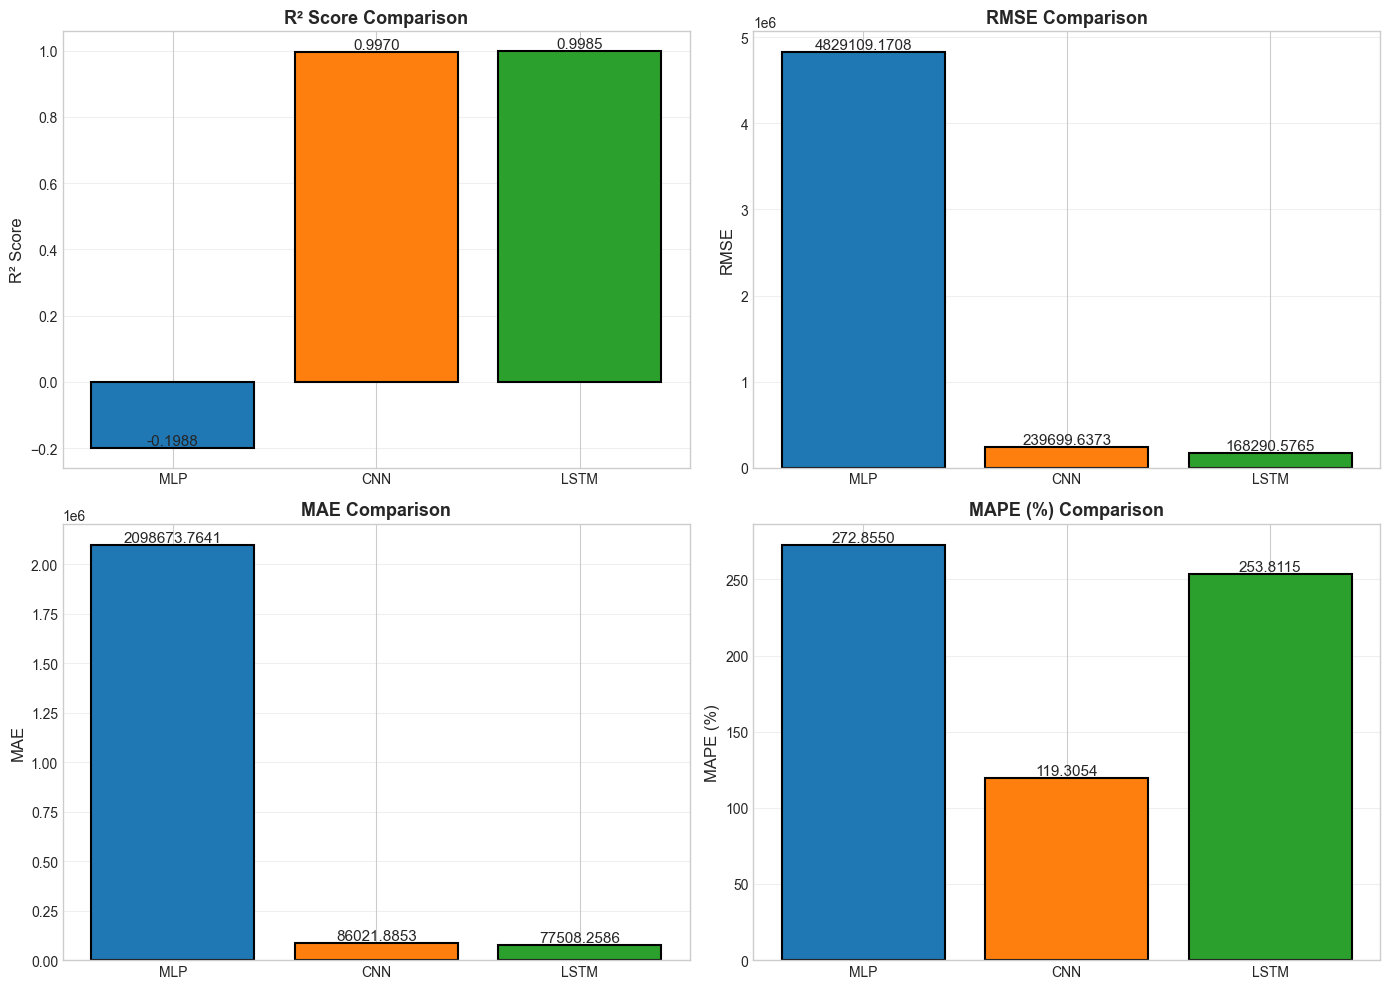

✓ Plot saved to 'DNN_Performance_Comparison.png'


In [ ]:
# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['R² Score', 'RMSE', 'MAE', 'MAPE (%)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = results[metric].values
    bars = ax.bar(['MLP', 'CNN', 'LSTM'], values, color=colors, edgecolor='black', linewidth=1.5)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=11)
    
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('DNN_Performance_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to 'DNN_Performance_Comparison.png'")

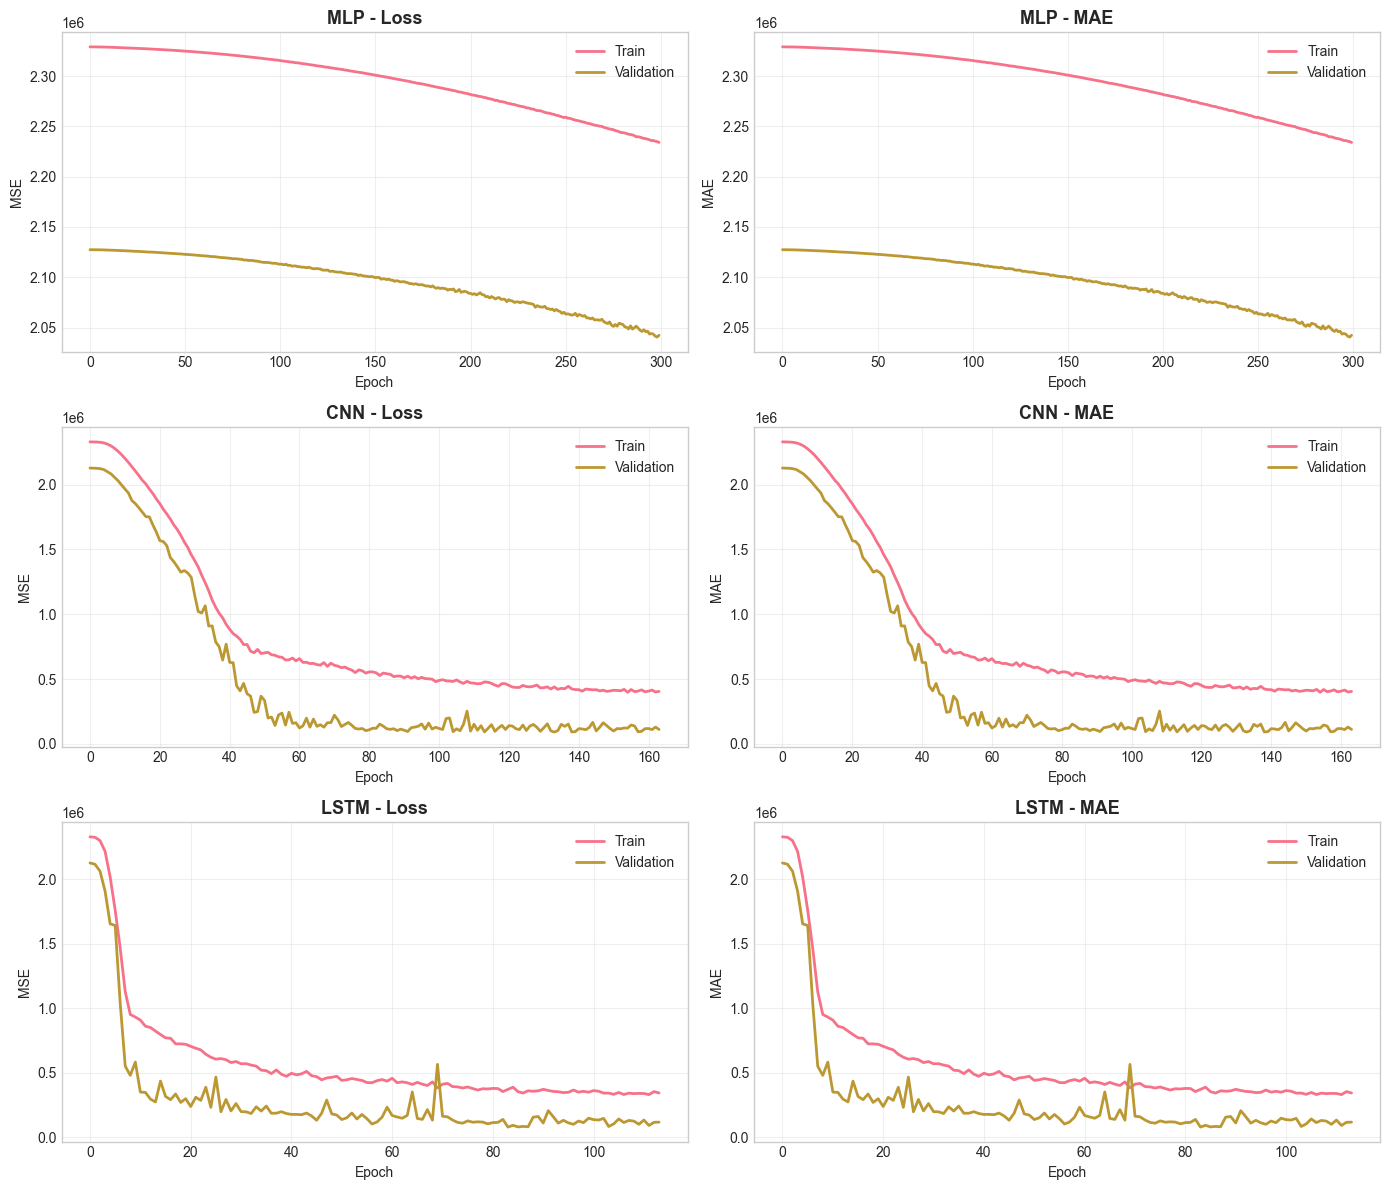

✓ Training curves saved to 'DNN_Training_Curves.png'


In [ ]:
# Training curves
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

histories = [
    ('MLP', mlp_history),
    ('CNN', cnn_history),
    ('LSTM', lstm_history)
]

for idx, (name, history) in enumerate(histories):
    # Loss
    axes[idx, 0].plot(history.history['loss'], label='Train', linewidth=2)
    axes[idx, 0].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[idx, 0].set_title(f'{name} - Loss', fontsize=13, fontweight='bold')
    axes[idx, 0].set_xlabel('Epoch')
    axes[idx, 0].set_ylabel('MSE')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # MAE
    axes[idx, 1].plot(history.history['mae'], label='Train', linewidth=2)
    axes[idx, 1].plot(history.history['val_mae'], label='Validation', linewidth=2)
    axes[idx, 1].set_title(f'{name} - MAE', fontsize=13, fontweight='bold')
    axes[idx, 1].set_xlabel('Epoch')
    axes[idx, 1].set_ylabel('MAE')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('DNN_Training_Curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training curves saved to 'DNN_Training_Curves.png'")

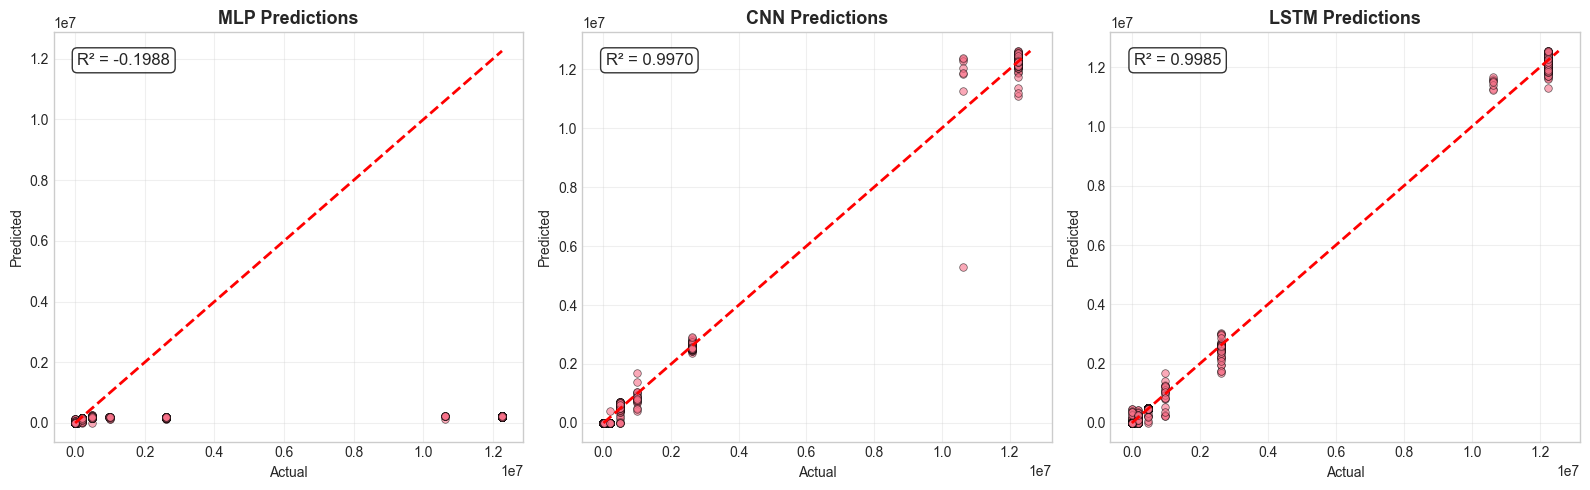

✓ Prediction plots saved to 'DNN_Predictions.png'


In [ ]:
# Prediction scatter plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

predictions = [
    ('MLP', y_test_pred_mlp, mlp_r2),
    ('CNN', y_test_pred_cnn, cnn_r2),
    ('LSTM', y_test_pred_lstm, lstm_r2)
]

for idx, (name, y_pred, r2) in enumerate(predictions):
    axes[idx].scatter(y_test, y_pred, alpha=0.6, s=30, edgecolors='k', linewidths=0.5)
    
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    axes[idx].text(0.05, 0.95, f'R² = {r2:.4f}', transform=axes[idx].transAxes,
                   fontsize=12, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    axes[idx].set_title(f'{name} Predictions', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Actual')
    axes[idx].set_ylabel('Predicted')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('DNN_Predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Prediction plots saved to 'DNN_Predictions.png'")

## 8. Summary

**Analysis Complete!**

Three deep neural network architectures were successfully trained and evaluated:

1. **MLP (Multi-Layer Perceptron)** - Feedforward architecture
2. **CNN (Convolutional Neural Network)** - 1D convolutions
3. **LSTM (Long Short-Term Memory)** - Bidirectional recurrent network

**Generated Outputs:**
- `DNN_Results_Comparison.csv` - Performance metrics table
- `DNN_Performance_Comparison.png` - Bar chart comparison
- `DNN_Training_Curves.png` - Training history plots
- `DNN_Predictions.png` - Scatter plots with R² scores

**Next Steps:**
1. Review the results table to identify the best model
2. Use the figures for your technical paper
3. Consider ensemble methods if models perform similarly
4. Fine-tune hyperparameters for the best-performing model